In [1]:
import pandas as pd
import numpy as np

In [14]:
import matplotlib.pyplot as plt 
from sklearn import svm
import seaborn as sns


In [3]:
df = pd.read_csv("machine_ID_1.csv")

del df["Unnamed: 0"]
df = df.drop('machineID', axis = 1)
df = df.drop('model', axis = 1)
df = df.drop('error1count', axis = 1)
df = df.drop('error2count', axis = 1)
df = df.drop('error3count', axis = 1)
df = df.drop('error4count', axis = 1)
df = df.drop('error5count', axis = 1)
df = df.drop('age', axis = 1)
df = df.drop('datetime', axis = 1)


df.head()

,voltmean,rotatemean,pressuremean,vibrationmean,voltsd,rotatesd,pressuresd,vibrationsd,failure,time_diff
0,169.733809,445.179865,96.797113,40.385160,11.233120,48.717395,10.079880,5.853209,False,3.0
1,170.525721,443.906847,97.667249,39.786670,12.591948,46.930282,9.406795,6.098173,False,6.0
2,170.049722,446.461279,96.906162,40.016513,13.277336,42.836780,9.071472,5.481724,False,9.0
3,170.341974,447.355315,96.229522,39.921963,13.817158,42.808633,8.256794,5.862312,False,12.0
4,170.060643,452.163407,96.357441,39.990470,14.792869,42.525293,8.669605,5.907157,False,15.0


In [4]:
'''df.index = df.datetime

df.head()

'''

'df.index = df.datetime\n\ndf.head()\n\n'

# Splitting data



In [5]:
from sklearn.model_selection import train_test_split


### "failure" as the label for predicting temperatures in y, data other than "failure" is taken as features using the drop() function in X.

In [6]:
y = df.failure
X = df.drop('failure', axis = 1)

# print

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2)
print("\nX_train:\n")
print(X_train.head())
print(X_train.shape)

print("\nX_test:\n")
print(X_test.head())
print(X_test.shape)


X_train:

        voltmean  rotatemean  pressuremean  vibrationmean     voltsd  \
2603  169.326968  434.570135     99.025950      39.900430  12.041993   
119   187.617588  437.688904    101.277466      40.567847  14.771306   
57    172.469287  448.688580    102.744125      38.567835  15.322055   
2249  171.648743  449.450847    100.523919      42.112406  15.353759   
1625  167.523911  458.382757    100.739234      41.625821  18.004011   

       rotatesd  pressuresd  vibrationsd  time_diff  
2603  64.583730   10.002570     4.284876     7812.0  
119   56.651800   10.916522     4.735935      360.0  
57    38.838107    8.834654     4.727937      174.0  
2249  57.549303    8.730168     6.124579     6750.0  
1625  47.931149    7.194907     5.100401     4878.0  
(2330, 9)

X_test:

        voltmean  rotatemean  pressuremean  vibrationmean     voltsd  \
707   166.997525  441.831035    100.090470      42.155216  14.648260   
56    173.392800  447.263257    103.144757      38.836725  13.217687

# svm model training

In [8]:
#Create a svm Classifier
clf = svm.SVC(kernel='linear') # Linear Kernel

#Train the model using the training sets
clf.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

In [9]:
from sklearn import metrics


In [10]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))


Accuracy: 0.9828473413379074


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test,y_pred))


[[571   0]
 [ 10   2]]


In [12]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.98      1.00      0.99       571
        True       1.00      0.17      0.29        12

    accuracy                           0.98       583
   macro avg       0.99      0.58      0.64       583
weighted avg       0.98      0.98      0.98       583



In [16]:
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[571,   0],
       [ 10,   2]], dtype=int64)

Text(0.5, 257.44, 'Predicted label')

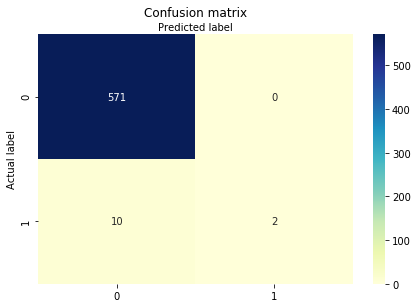

In [18]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')